In [1]:
import numpy as np
import pandas as pd
from plotnine import *
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import chi2

In [8]:
growth_analysis = pd.read_csv("../Datasets/Exercise2_datasets/Exercise7DATA.csv", sep='\t')
growth_analysis.head()

,strain,growth_rate,gene_1,gene_14,gene_27,gene_40,gene_54,gene_67,gene_80,gene_94,...,gene_13194,gene_13207,gene_13220,gene_13234,gene_13247,gene_13260,gene_13274,gene_13287,gene_13300,gene_13314
0,seg_01B,6.720447,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,seg_01C,7.429273,True,True,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,seg_01D,6.905589,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,seg_02B,4.924324,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,seg_02C,4.413402,True,True,True,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True


In [9]:
growth_analysis = growth_analysis.rename(
    columns={
    'strain': 'yeast_ID',
    'gene_5211': 'gene_A',
    'gene_5091': 'gene_B',
    'gene_1653': 'gene_C'
    }
)[['yeast_ID', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']]

growth_analysis.head()


,yeast_ID,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


In [10]:
growth_analysis = pd.melt(
growth_analysis,
id_vars=['yeast_ID', 'growth_rate'],
var_name='gene',
value_name='variant'
)

growth_analysis.head()

,yeast_ID,growth_rate,gene,variant
0,seg_01B,6.720447,gene_A,False
1,seg_01C,7.429273,gene_A,False
2,seg_01D,6.905589,gene_A,True
3,seg_02B,4.924324,gene_A,False
4,seg_02C,4.413402,gene_A,False


In [12]:
growth_analysis['variant'] = growth_analysis['variant'].replace(
{False: "LAB", True: "WILD"}
)

growth_analysis.head()

,yeast_ID,growth_rate,gene,variant
0,seg_01B,6.720447,gene_A,LAB
1,seg_01C,7.429273,gene_A,LAB
2,seg_01D,6.905589,gene_A,WILD
3,seg_02B,4.924324,gene_A,LAB
4,seg_02C,4.413402,gene_A,LAB


------

# Section 01 - Permutation test of growth rate difference

This exercise sheet uses a subset of the yeast dataset, which analyses the genetic determinants of yeast
growth rates. We look at three genes, for simplicity called A, B and C, of which each yeast can have one
of two variants: “wild” or “lab”. We want to determine whether the different variants of these genes are
associated with differences in growth rate.

1. The following code recreates the example shown in the lecture to test the association of the variant of
gene_A with the growth rate difference. Note that the code is written using functions, meaning that it
will work for any gene name, not just gene_A. Read it carefully to understand what happens in each
function. Then execute the code.

In [13]:
# Function to plot growth vs genotype for one gene
def plot_growth_one_gene(gene_name):
    data = growth_analysis[growth_analysis['gene'] == gene_name]
    g = (
        ggplot(data, aes(x='variant', y='growth_rate'))
        + geom_boxplot()
        + labs(title=f"Growth Rate by {gene_name}", x=gene_name, y="Growth Rate")
        + scale_x_discrete(labels={"LAB": "Lab variant", "WILD": "Wild variant"})
        + theme_bw(base_size=16)
    )
    g.show()

In [14]:
# Function to calculate the difference of the medians of two variants
def median_diff(df):
    medians = df.groupby('variant')['growth_rate'].median()
    return medians['WILD'] - medians['LAB']

In [24]:
# Function to permute the table, plot the resulting histogram and compute a p-value
def p_val_medians(gene_name, N_permu=1000):
    # It will return both a pvalue and plot a histogram of T_star
    # reduce to gene of interest
    np.random.seed(0)
    df = growth_analysis[growth_analysis['gene'] == gene_name].copy()
    T_ref = median_diff(df)


    # Permutation loop
    T_star = []
    temp_df = df.copy()
    variants = df['variant'].values
    
    for _ in range(N_permu):
        temp_df['variant'] = np.random.permutation(variants)
        T_star.append(median_diff(temp_df))
    
    T_star = np.array(T_star)
    
    # Plotting
    g = (
        ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
        + geom_histogram(bins=30)
        + geom_vline(xintercept=T_ref, color='red')
        + xlim(-3, 3)
    )
    g.show()
    # Compute and return the p value
    # First compute each tail seperately

    p_right = (np.sum(T_star >= T_ref) + 1) / (N_permu + 1)
    p_left = (np.sum(T_star <= T_ref) + 1) / (N_permu + 1)
    # Then combine the above to obtain the double sided p-value.
    
    p_val = 2 * min(p_right, p_left)
    return p_val

2. Using the code above, plot and test whether having wild variants of genes gene_B and gene_C are
associated with growth. Interpret your results.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


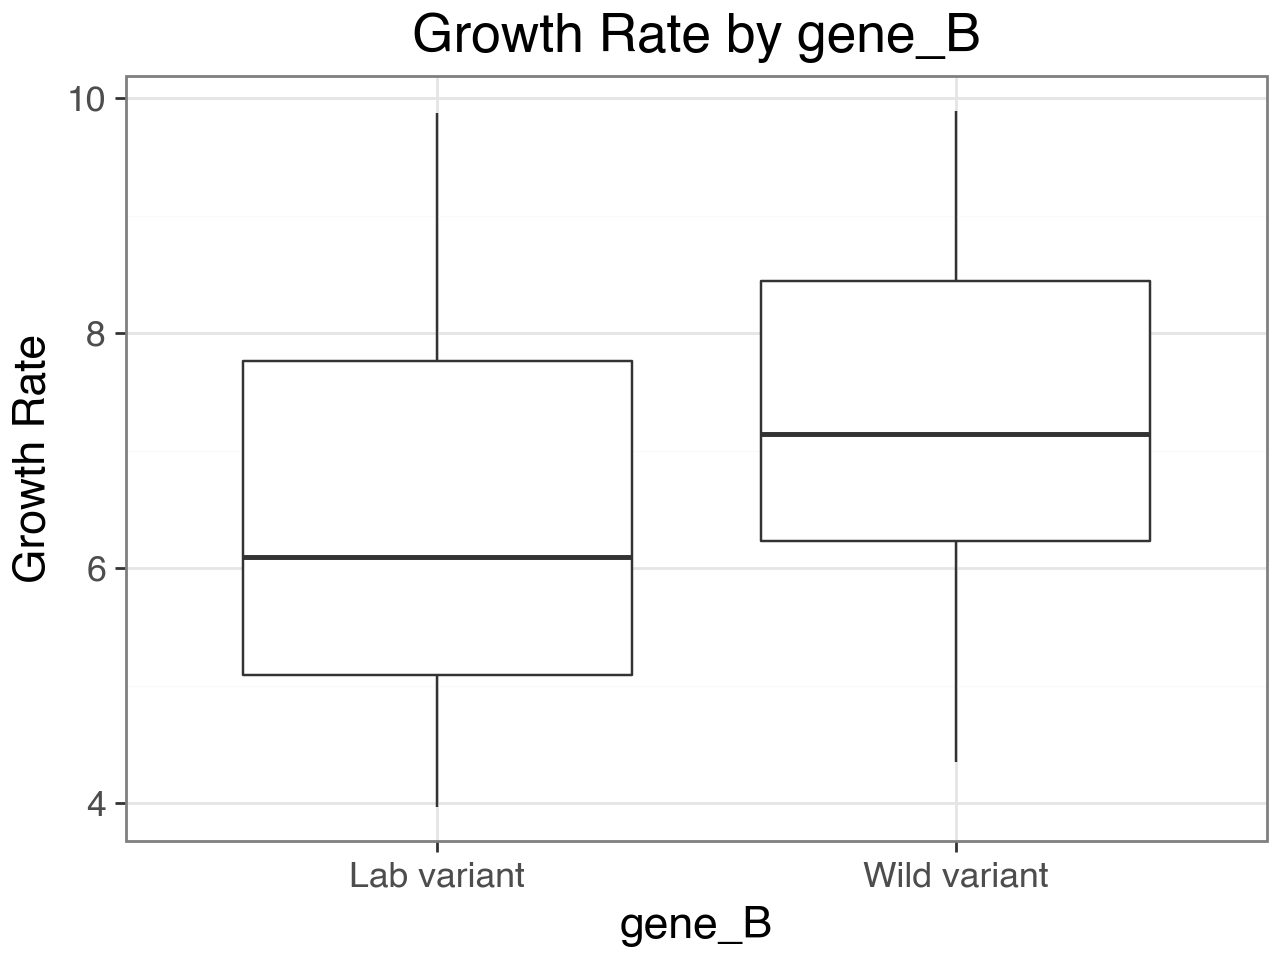

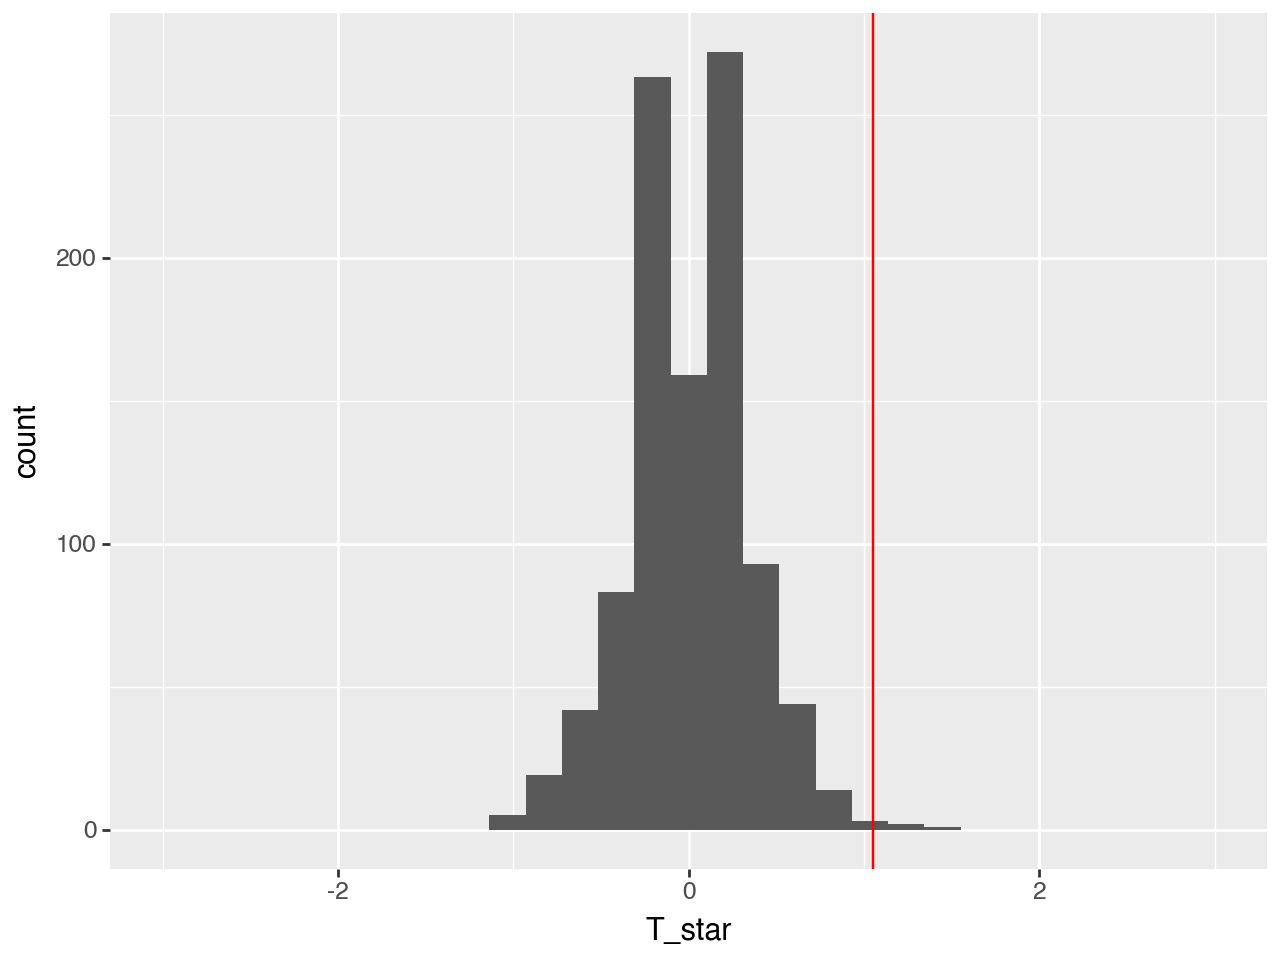

np.float64(0.00999000999000999)

In [25]:
plot_growth_one_gene('gene_B')

p_val_medians('gene_B')

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


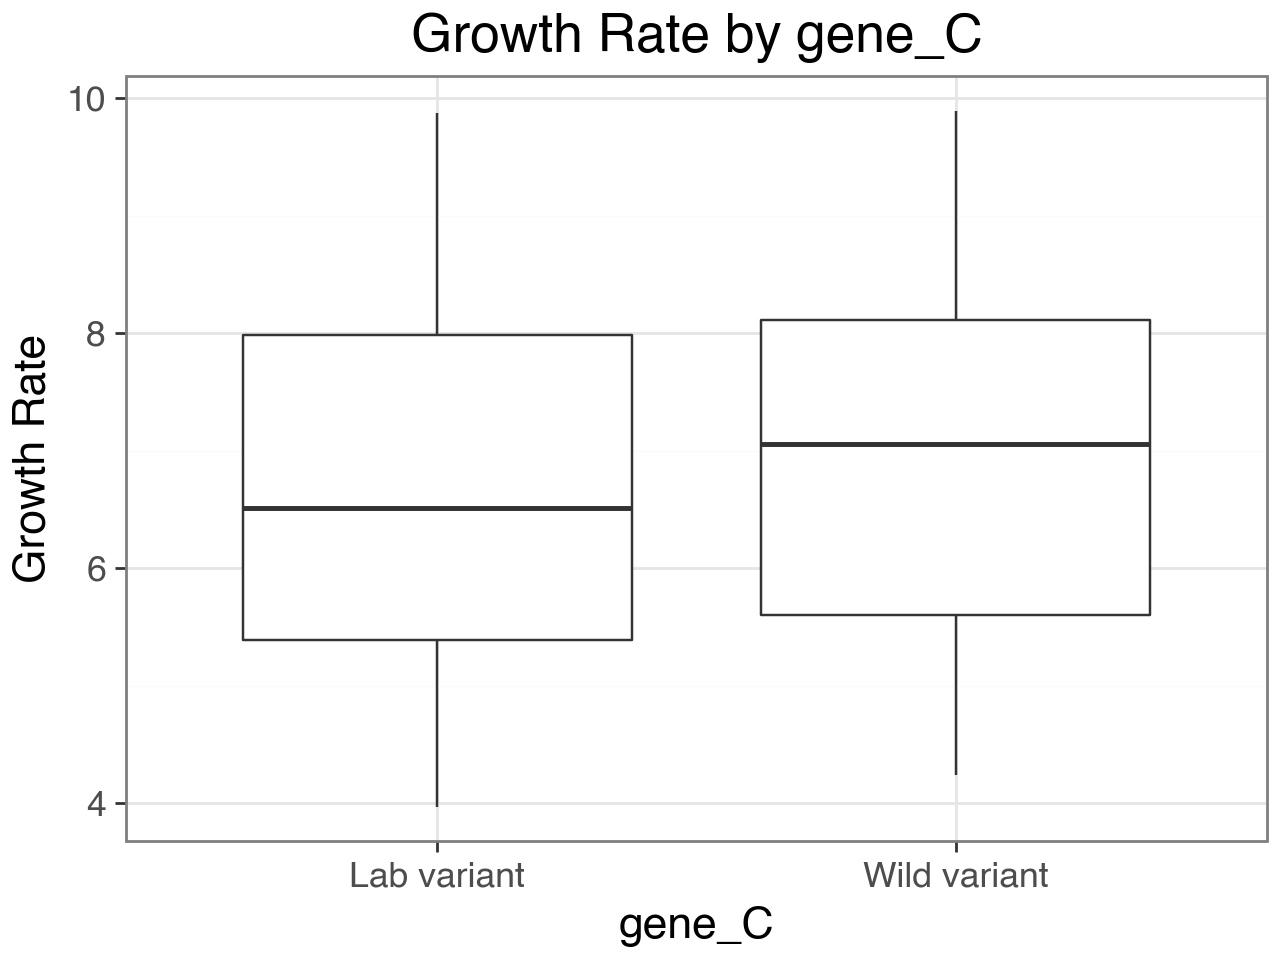

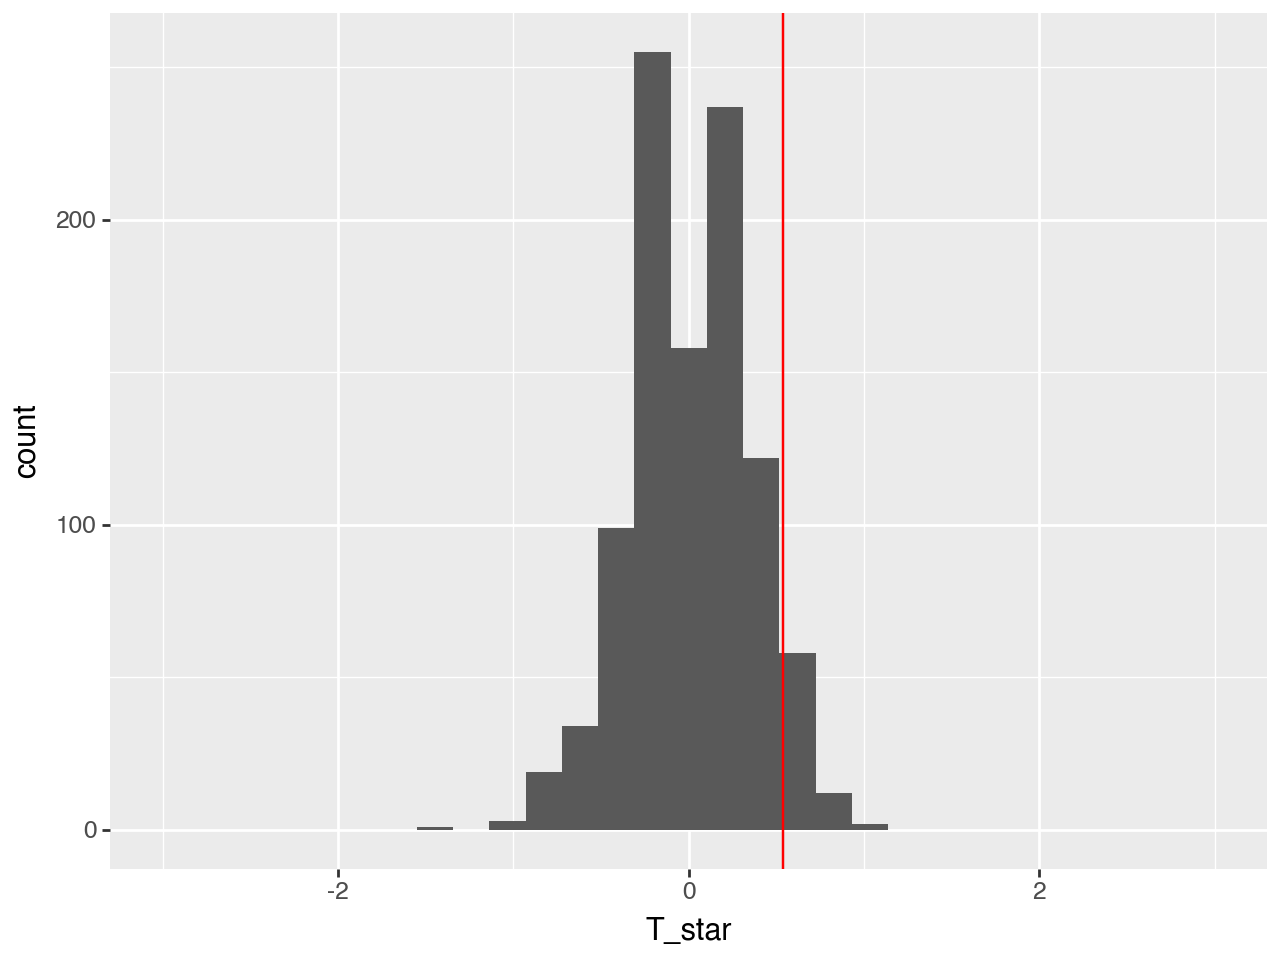

np.float64(0.11988011988011989)

In [26]:
plot_growth_one_gene('gene_C')

p_val_medians('gene_C')

-------

# Section 02 - Permutation test of gene association

We just concluded that having wild variants of both gene A and gene B is significantly associated with
growth. 

Did we find variants for two genes causing improved growth? 

This result could be influenced by a phenomenon called linkage, a common source of confounding in genomics. Linkage occurs when genes are inherited together because they are located close to each other on the same chromosome. 

Genes that are close tend to be passed down together, while genes that are far apart or on different chromosomes are
usually inherited independently.

In this case, whether gene_A has a ‘wild’ or ‘lab’ variant might depend on whether gene_B has a ‘wild’
or ‘lab’ variant, simply because the two genes may be linked, and therefore tend to be inherited together
in the dataset.

1. Does the frequency of the wild variant on gene A seem to depend on which variant gene B has? Propose
a plot and discuss. No statistical evaluation is requested for this question.

In [27]:
growth_merged = (
    growth_analysis[growth_analysis['gene']
    .isin(['gene_A', 'gene_B'])]
    .pivot(
        index=['yeast_ID', 'growth_rate'],
        columns='gene',
        values='variant'
)
.reset_index()
)

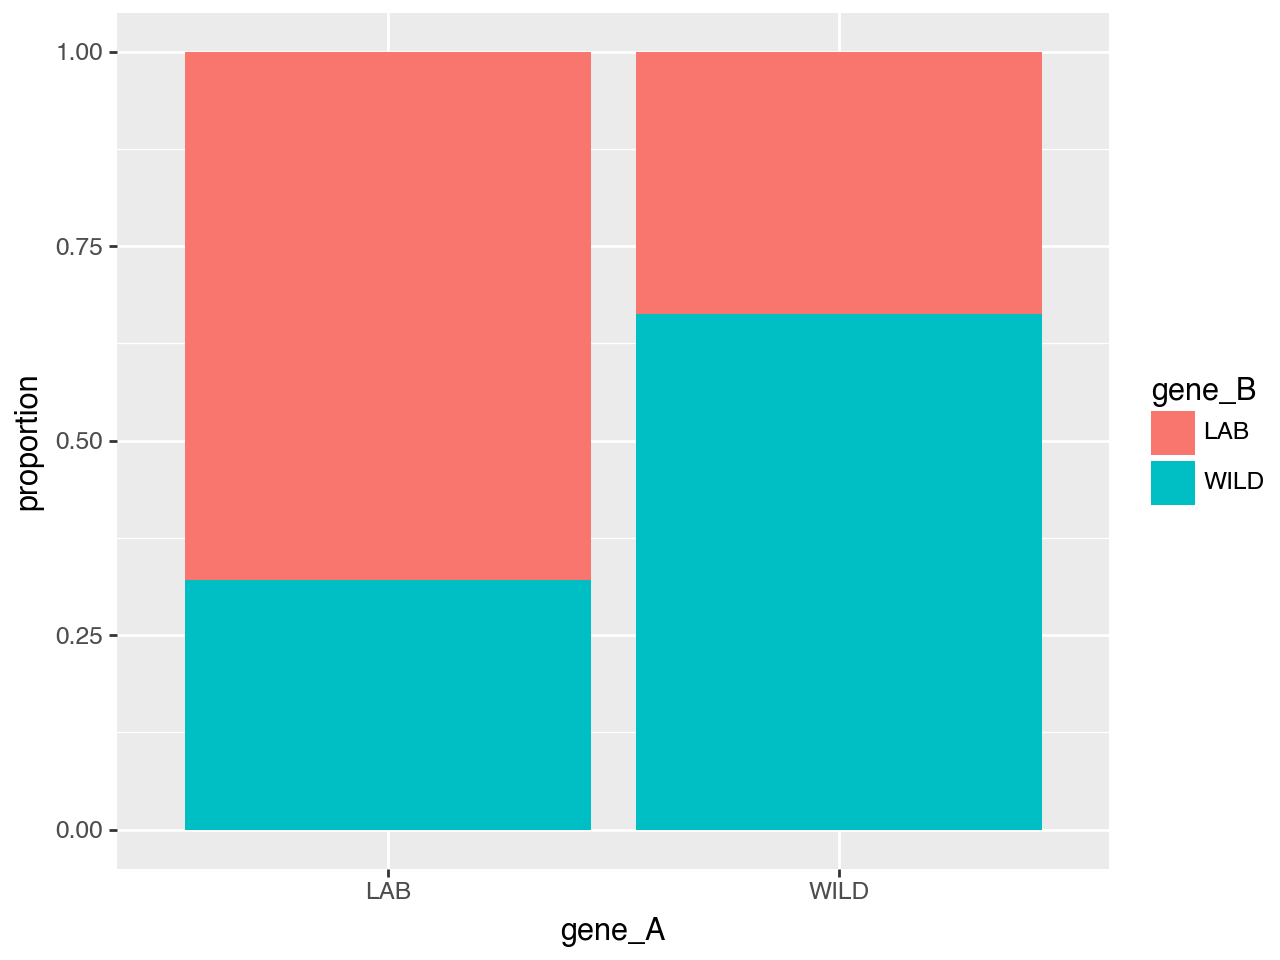

In [31]:
(
    ggplot(growth_merged, aes('gene_A', fill = 'gene_B')) +
    geom_bar(position = 'fill') + 
    labs(y="proportion")
)

2. To rigorously investigate the issue of linkage in our dataset, test if gene_A significantly associates
with gene_B. Define a null hypothesis, a statistic and use permutation testing to answer the question.
Strengthen your answer with a relevant plot.

In [41]:
growth_analysis.head()

growth2 = (
    growth_analysis[growth_analysis['gene'].isin(['gene_A', 'gene_B'])]
    .pivot(
        index= ['yeast_ID', 'growth_rate'],
        columns = 'gene',
        values = 'variant'
    ).reset_index()
)

T_ref = (growth2['gene_A'] == growth2['gene_B']).mean()

display(T_ref,
        growth2.head())

np.float64(0.6708860759493671)

gene,yeast_ID,growth_rate,gene_A,gene_B
0,seg_01B,6.720447,LAB,LAB
1,seg_01C,7.429273,LAB,LAB
2,seg_01D,6.905589,WILD,WILD
3,seg_02B,4.924324,LAB,WILD
4,seg_02C,4.413402,LAB,LAB


In [68]:
N_permu = 10000
gene_B_values = growth2['gene_B'].values

T_star = np.array([
    (growth2['gene_A'] == np.random.permutation(gene_B_values)).mean() for _ in range(N_permu)
])

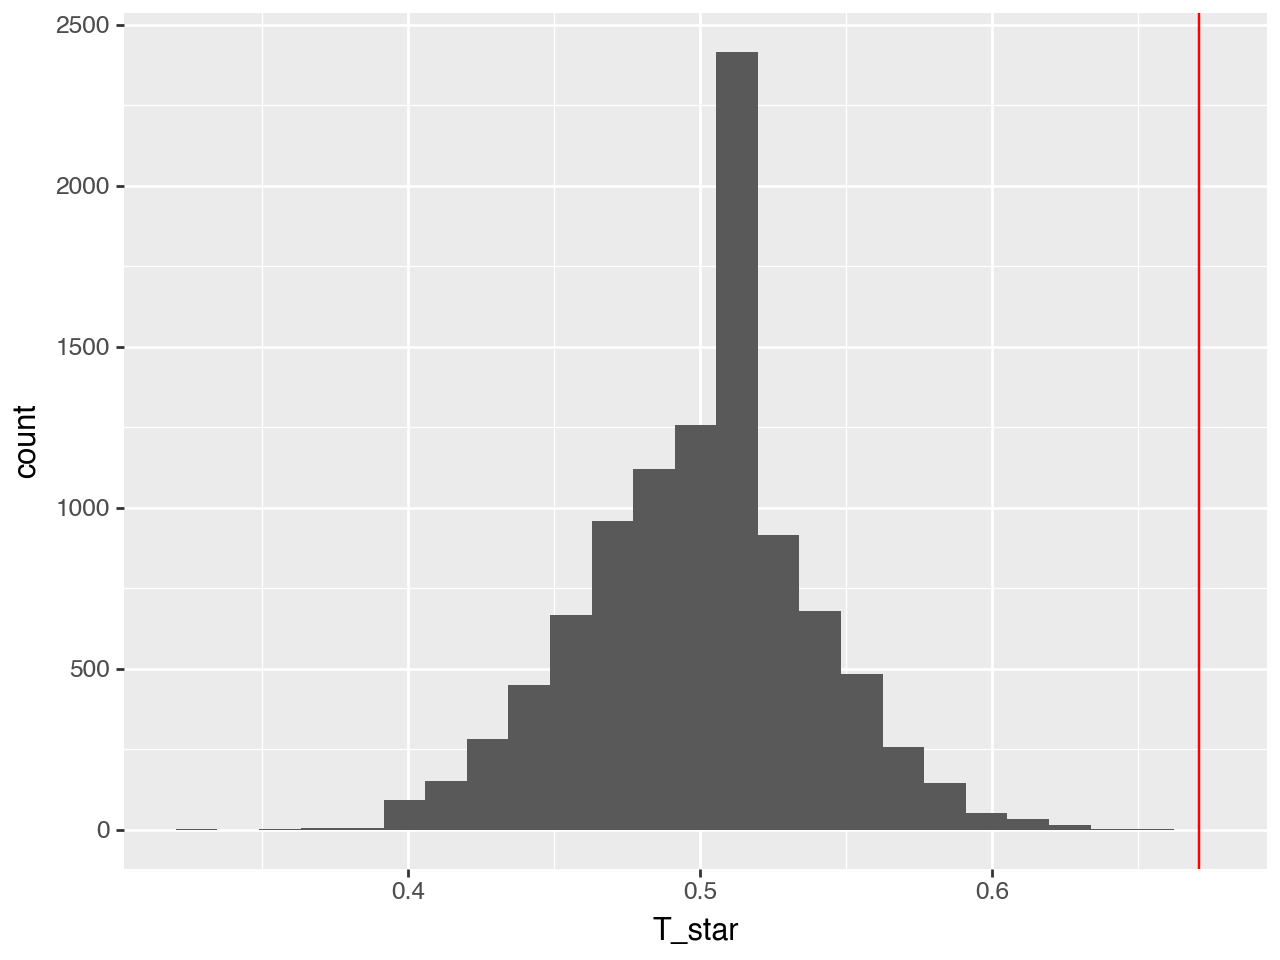

In [69]:
g = (
    ggplot( pd.DataFrame({'T_star': T_star}), aes('T_star')) + 
    geom_histogram(bins = 25) + 
    geom_vline(xintercept = T_ref, color = 'red')
)

g.show()

In [70]:
p_val = (np.sum(T_star >= T_ref)+1) / (N_permu + 1)
p_val

np.float64(9.999000099990002e-05)

-------

# Section 03 - Controlling for a 3rd variable

1. We found that having wild variants of gene_A and gene_B is associated with growth. However, we
also found that both genes are associated with each other. Thus, the association of one of these genes
with growth could be explained away by the association of the other one with growth.

Now, we would like to know if gene_B still associates with growth when conditioned on gene_A. Define
a null hypothesis, a statistic and use permutation testing to answer the question. Strengthen your answer
with a relevant plot. You can use the merged data table created in section 2.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_jitter : Removed 4 rows containing missing values.


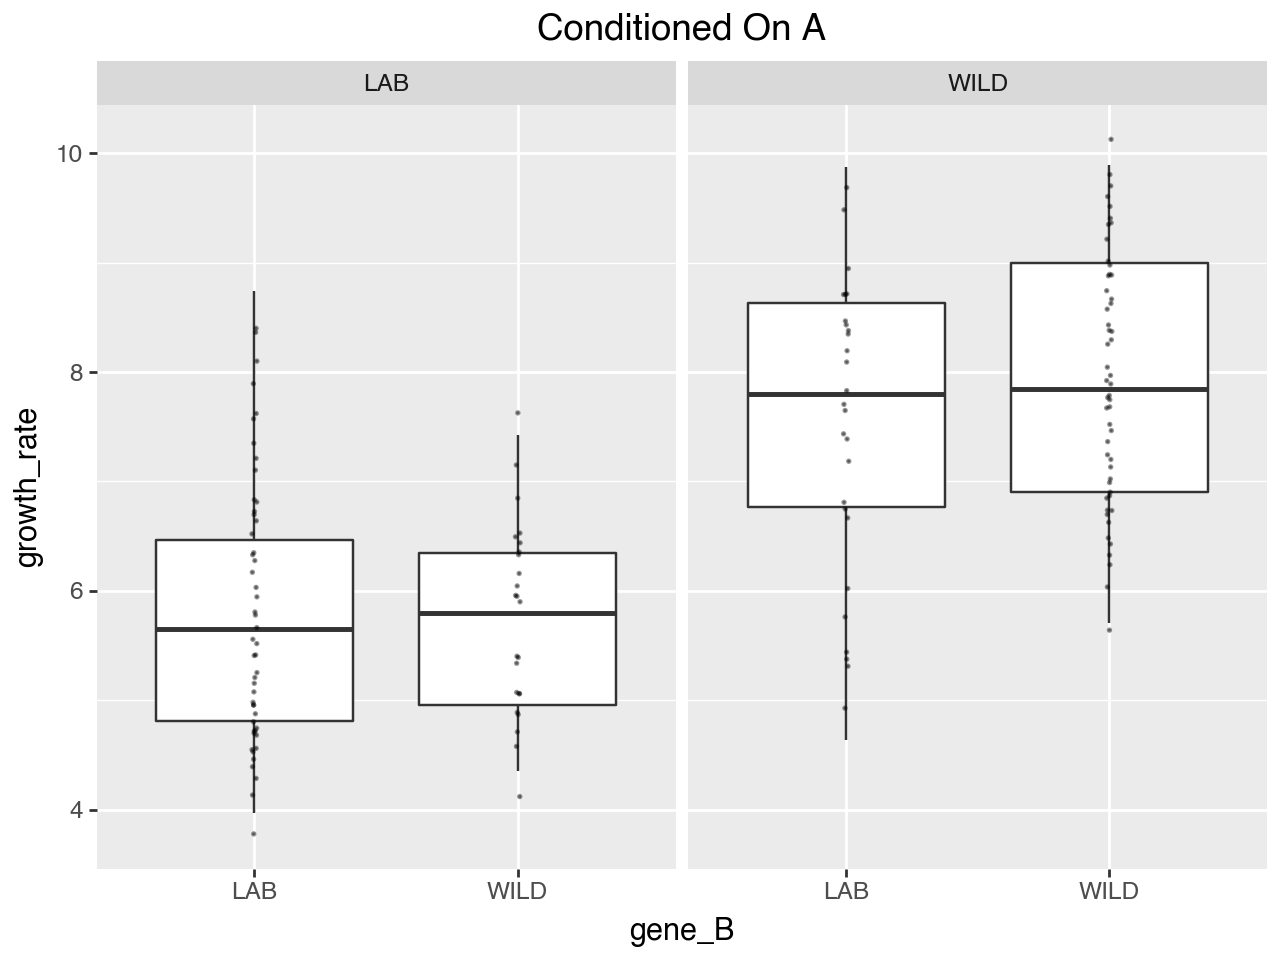

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_jitter : Removed 4 rows containing missing values.


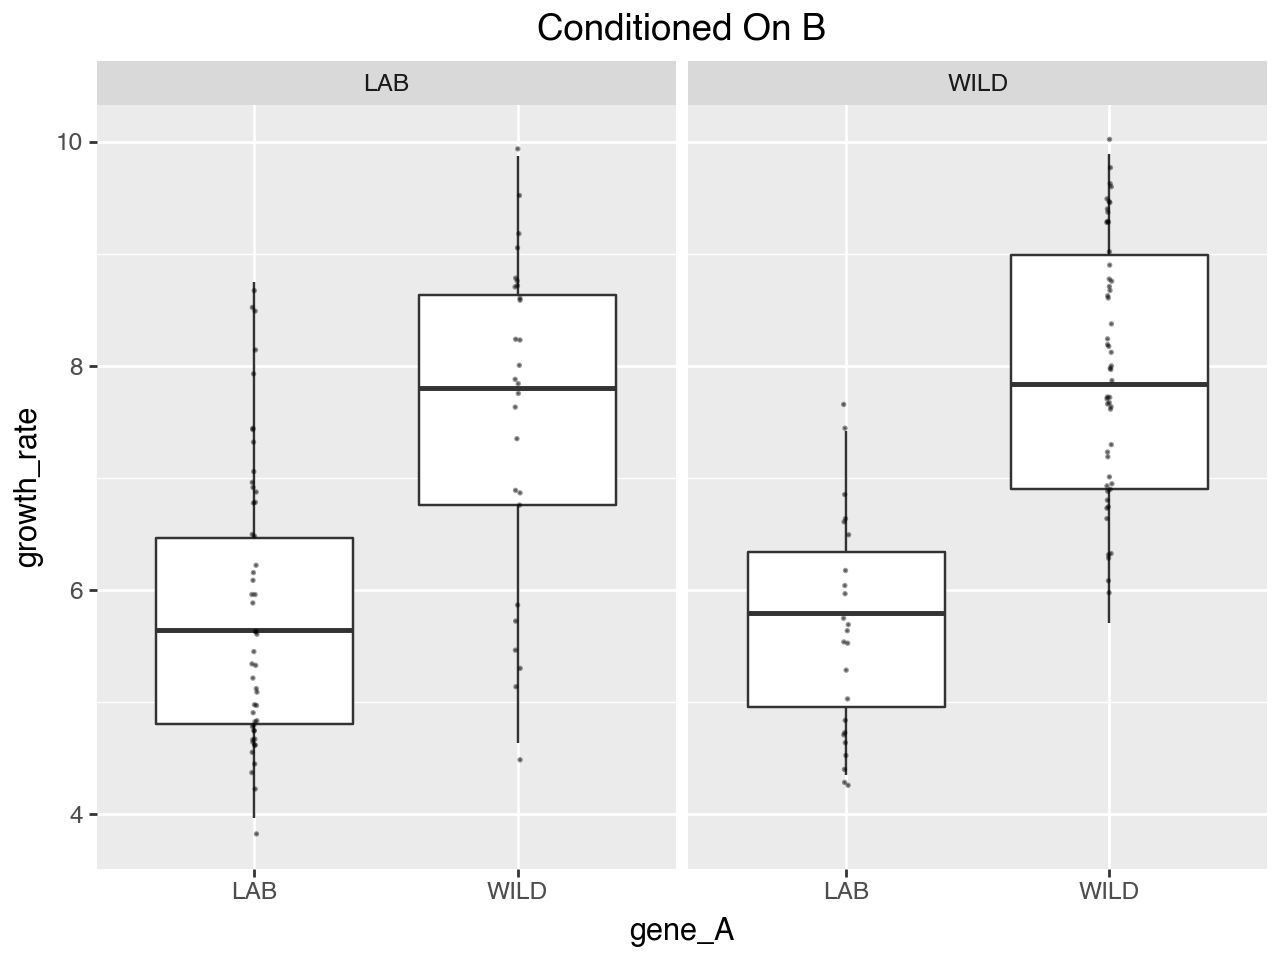

In [80]:
display((
    ggplot(growth2, aes('gene_B', 'growth_rate')) + 
    geom_boxplot() +
    facet_wrap('~gene_A') +
    geom_jitter(alpha = 0.4, size = 0.1, width = 0.01) +
    labs(title = 'Conditioned On A')
)
,
(
    ggplot(growth2, aes('gene_A', 'growth_rate')) + 
    geom_boxplot() +
    facet_wrap('~gene_B') +
    geom_jitter(alpha = 0.4, size = 0.1, width = 0.01) +
    labs(title = 'Conditioned On B')
)
)

In [81]:
def compute_stratified_difference(stratified_df):
    piv = stratified_df.pivot(
        index='condition_gene',
        columns='test_gene',
        values='median_growth'
    )

    lab_cond = piv.loc['LAB', 'WILD'] - piv.loc['LAB', 'LAB']
    wild_cond = piv.loc['WILD', 'WILD'] - piv.loc['WILD', 'LAB']
    
    return np.mean([lab_cond, wild_cond])

In [96]:
(
growth2.rename(columns = {'gene_A':'condition_gene', 'gene_B':'test_gene'})
       .groupby(["test_gene", "condition_gene"])['growth_rate']
       .median()
       .reset_index(name='median_growth')
)

,test_gene,condition_gene,median_growth
0,LAB,LAB,5.649665
1,LAB,WILD,7.802196
2,WILD,LAB,5.794220
3,WILD,WILD,7.841169


In [90]:
def p_val_condition_on(test_gene="gene_B", condition_gene="gene_A", N_permu=1000):
    conditioned_dt = growth2.copy()
    # On the growth vs genotype case, conditioned on another gene variant:
    ## Ho: The growth rate are the same for both genotypes at the test gene
    ## independent of the genotype of the conditioned gene

    ## Tref: mean across subgroups of {median(growth on Wild) - median(growth on Lab)},
    ## for each gene
    # Prepare data table
    
    conditioned_dt = conditioned_dt.rename(
        columns={test_gene: "test_gene", condition_gene: "condition_gene"}
    )

    # Get T_ref
    median_ref = (
        conditioned_dt
        .groupby(["test_gene", "condition_gene"])['growth_rate']
        .median()
        .reset_index(name='median_growth')
    )
    T_ref = compute_stratified_difference(median_ref)

    # Do permutations conditioned on the other gene
    T_star = []
    temp_dt = conditioned_dt.copy()
    
    for i in range(N_permu):
    # Shuffle test_gene within condition_gene groups
        temp_dt["test_gene"] = (
            temp_dt
            .groupby("condition_gene")["test_gene"]
            .transform(np.random.permutation)
        )
        
        medians = (
            temp_dt
            .groupby(["test_gene", "condition_gene"])['growth_rate']
            .median()
            .reset_index(name='median_growth')
        )
        
        T_star.append(compute_stratified_difference(medians))
    
    T_star = np.array(T_star)

    # Plot
    g = (
        ggplot(pd.DataFrame({'T_star': T_star}), aes('T_star'))
                + geom_histogram()
                + geom_vline(aes(xintercept=T_ref, color='"T_ref"'))
        )
    
    g.show()
    
    # P-value
    p_val = (np.sum(T_star >= T_ref) + 1) / (N_permu + 1)
    return p_val

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 20'. Pick better value with 'binwidth'.


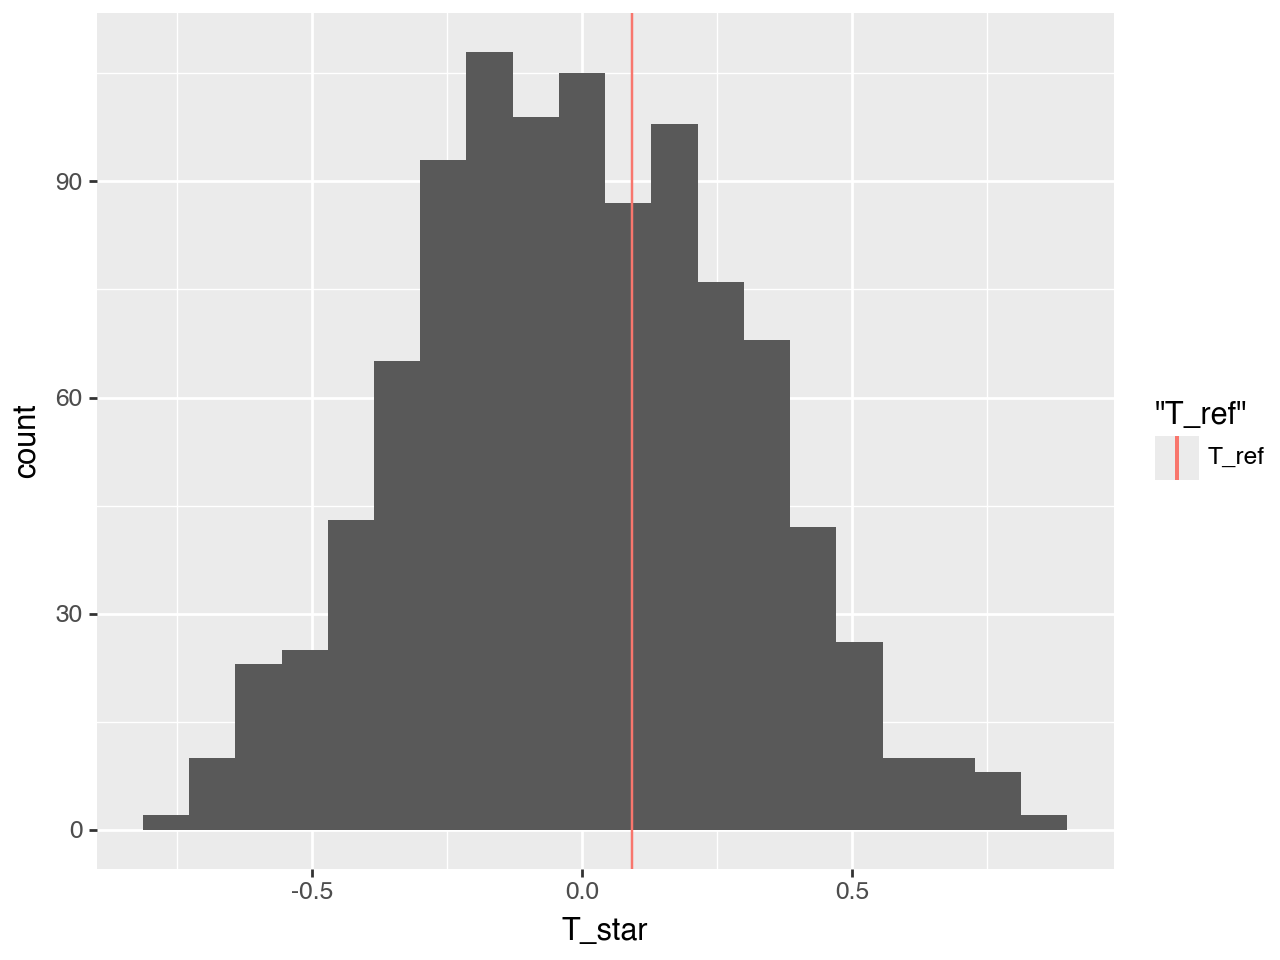

np.float64(0.3756243756243756)

In [91]:
p_val_condition_on(test_gene='gene_B', condition_gene= 'gene_A')

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 18'. Pick better value with 'binwidth'.


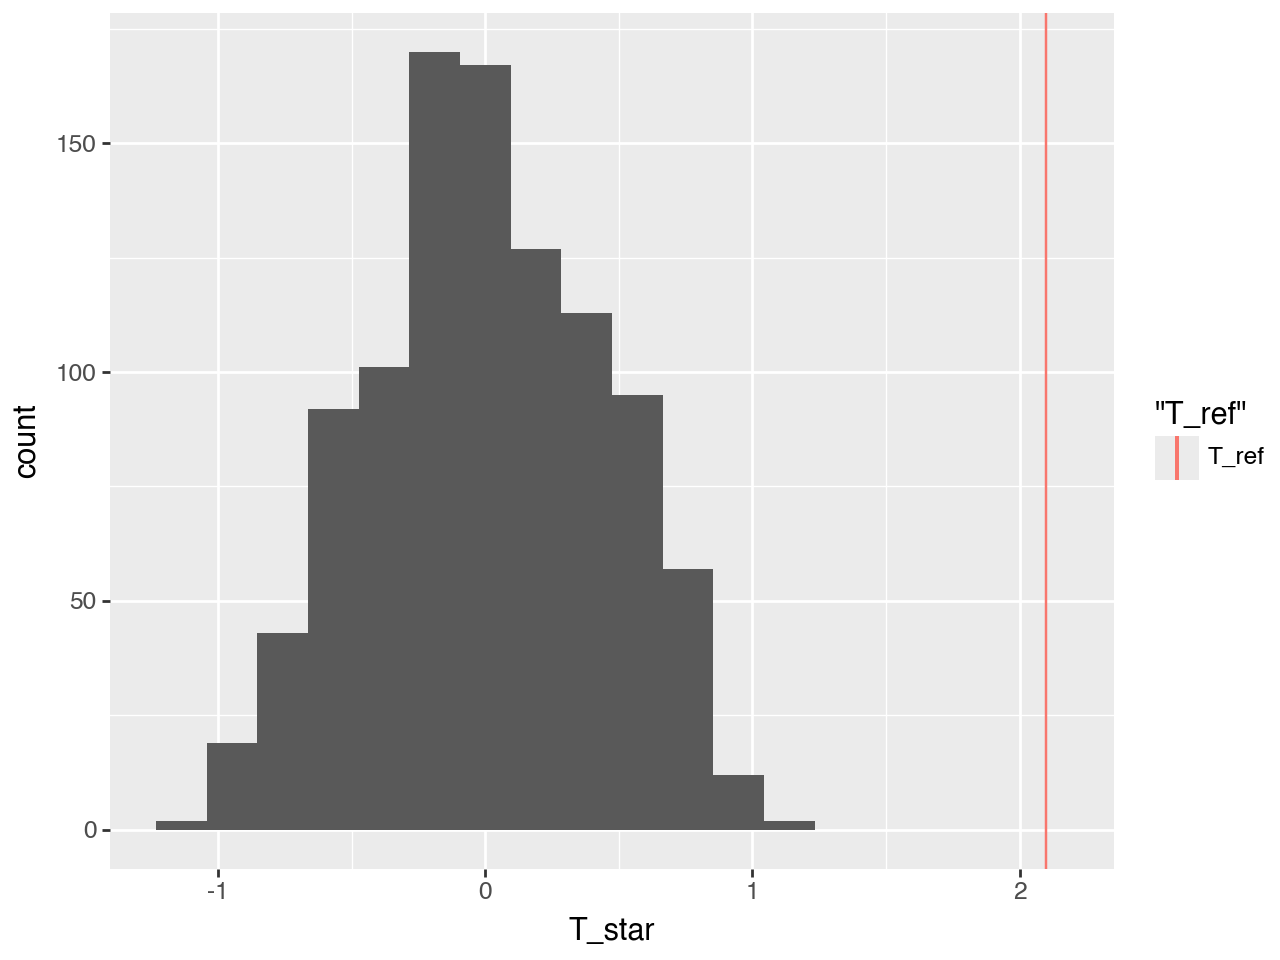

np.float64(0.000999000999000999)

In [93]:
p_val_condition_on(test_gene='gene_A', condition_gene= 'gene_B')

-------

# Section 04 - Confidence Intervals

1. Estimate 95% equi-tailed confidence intervals for the difference of the medians of growth for each
variant of the gene_A. Use the case resampling bootstrap scheme and report bootstrap percentile intervals.
Propose a visualization of the results. Try it also with gene_B and gene_C.

In [97]:
# Function to calculate the difference of the medians of two genotypes
def median_diff(df):
    medians = df.groupby('variant')['growth_rate'].median()
    
    return medians['WILD'] - medians['LAB']

# Bootstrap and compute statistic
def boot(df, statistic, B=999):
    return np.array([
        statistic(df.sample(frac=1, replace=True))
        for _ in range(B)
    ])

def confint(Tstar, alpha=0.05):
    return np.quantile(Tstar, [alpha/2, 1 - alpha/2])

def conf_int_plot(gene_name):
    # select gene of interest
    permuted_table = growth_analysis[growth_analysis['gene'] == gene_name].copy()

    # Bootstrap 999 times and compute the median (mystat)
    T_star = boot(permuted_table, median_diff)
    T_ref = median_diff(permuted_table)
    CI_lab = confint(T_star)

    # Plot histogram, add median and confidence interval as vertical lines
    g = (
        ggplot(pd.DataFrame({'T_star': T_star}), aes(x='T_star'))
        + geom_histogram()
        + geom_vline(xintercept=T_ref, color="red")
        + geom_vline(xintercept=CI_lab[0], color="blue", linetype="dashed")
        + geom_vline(xintercept=CI_lab[1], color="blue", linetype="dashed")
    )
    
    g.show()    

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 22'. Pick better value with 'binwidth'.


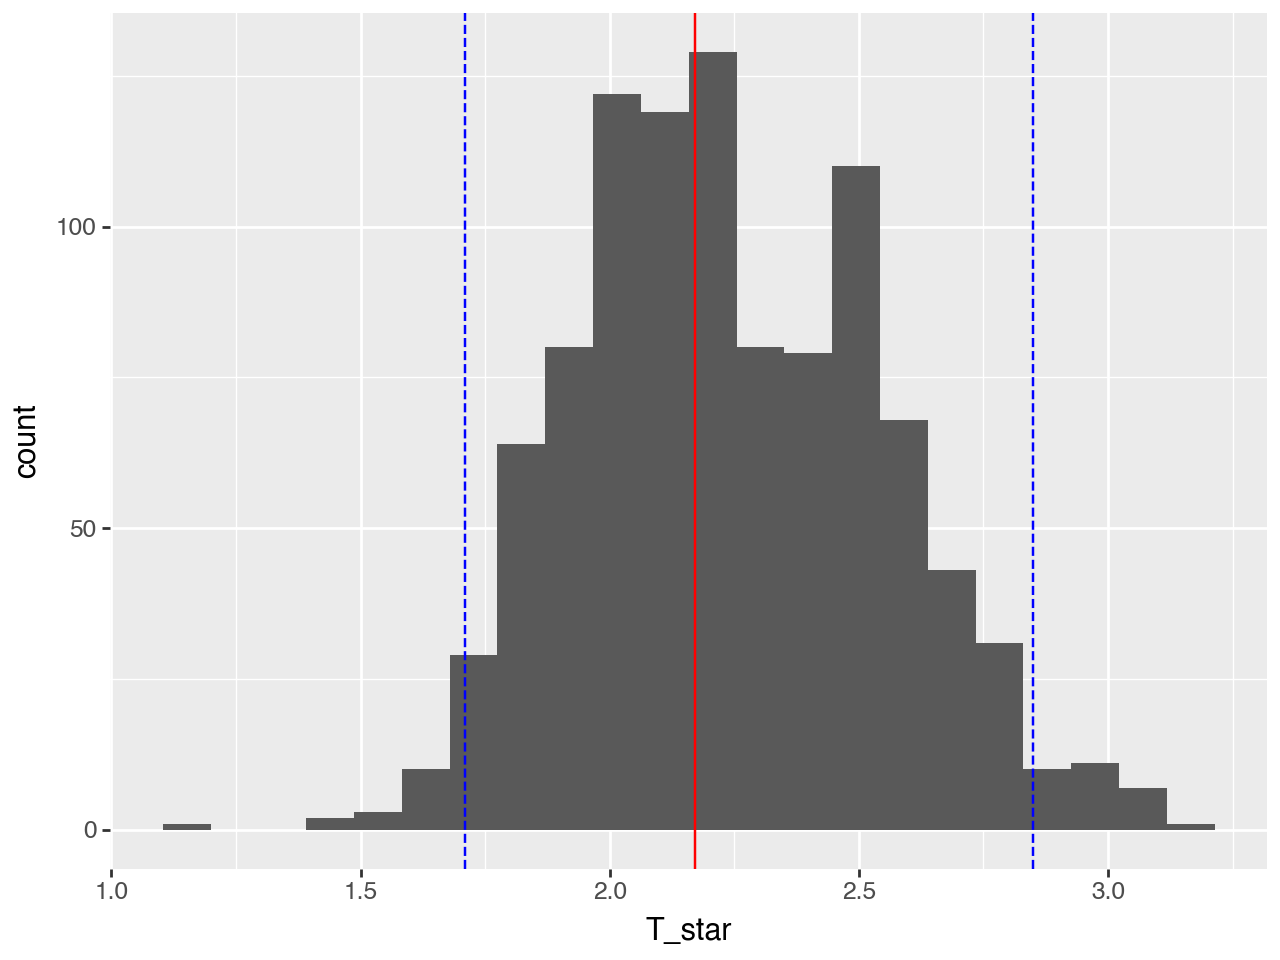

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 20'. Pick better value with 'binwidth'.


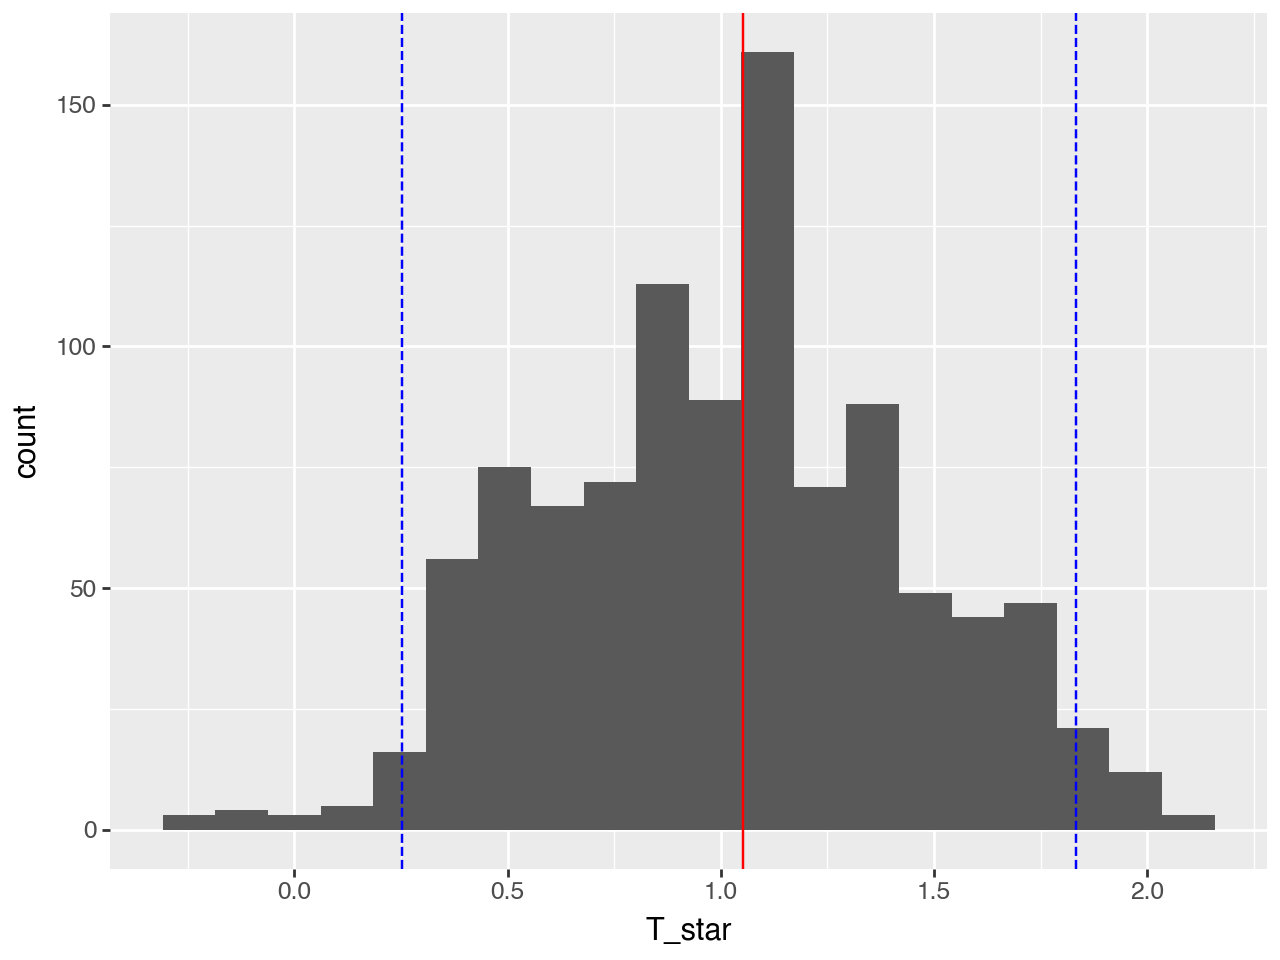

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 28'. Pick better value with 'binwidth'.


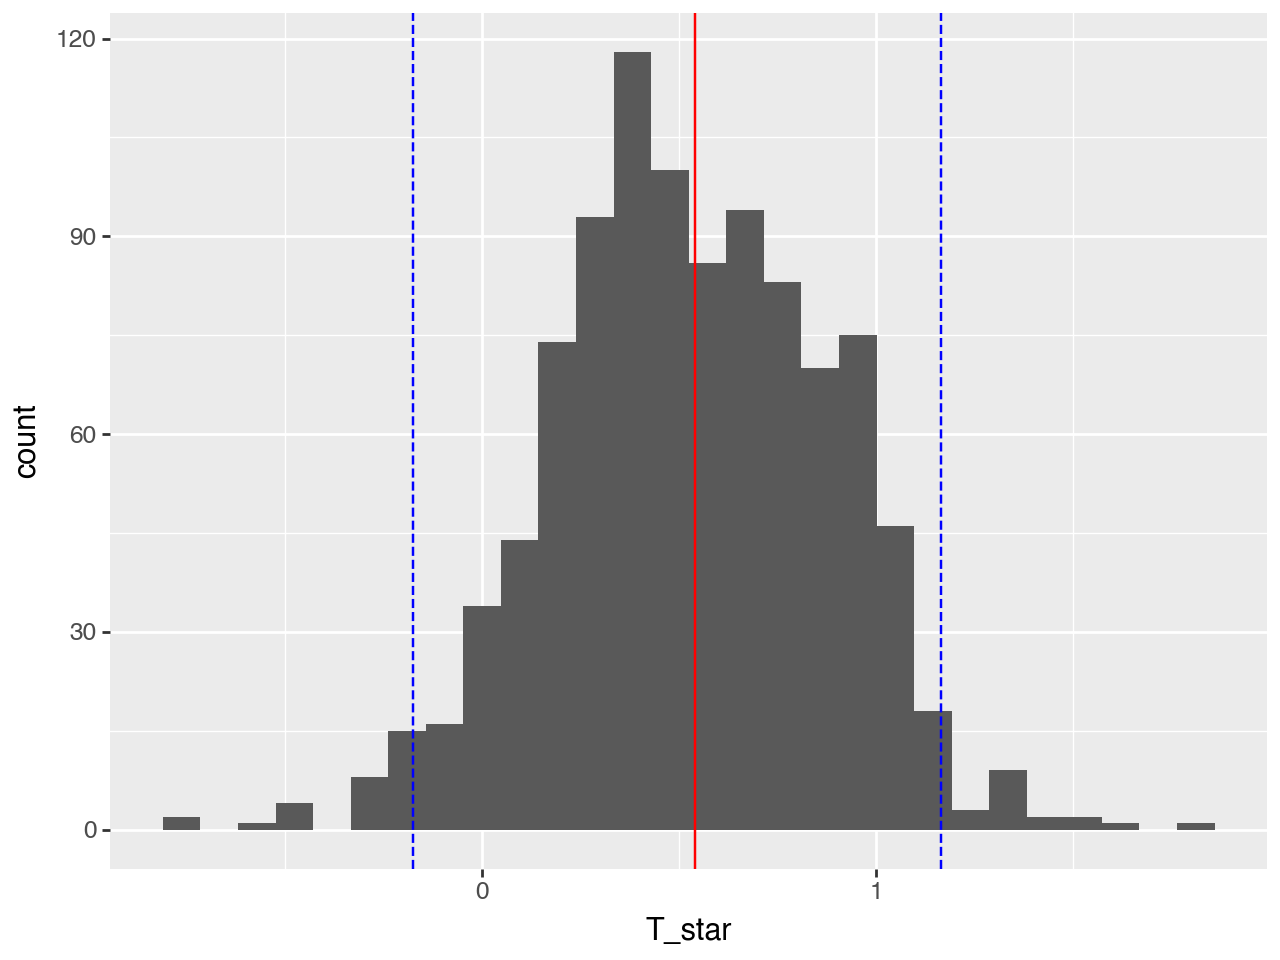

In [98]:
conf_int_plot("gene_A")
# We see that the confidence intervals doesn't overlap 0
conf_int_plot("gene_B")
# We see that the confidence intervals doesn't overlap 0
conf_int_plot("gene_C")
# The intervals clearly overlaps 0